# 07 — Wildfire Feature Engineering

**Phase 4, Step 1.** Builds the daily per-city training table for the wildfire
models.

**Inputs** (from earlier phases):
- `data/interim/weather_daily_clean.csv` — daily weather (Phase 2.1)
- `data/interim/firms.csv` — VIIRS fire hotspots (Phase 1)
- `data/interim/ndvi.csv` — MODIS NDVI per city (Phase 1)
- `data/interim/roads.csv` — human-access road density (Phase 1)
- `data/interim/population.csv` — population density per city-year (Phase 1)
- `data/interim/lightning.csv` — monthly thunder-hours grid (Phase 1)
- `data/interim/cities_reference.csv` — city centroids

**Output**: `data/processed/wildfire_features.csv`

---

## Target definition

For each (city, date), we label:

| Column | Type | Definition |
|---|---|---|
| `fire_occurred` | binary {0,1} | ≥1 FIRMS **vegetation** hotspot (type=0, confidence ≠ "l") within `RADIUS_KM` km of the city on that date |
| `fire_count` | non-neg int | count of such hotspots |
| `fire_frp_total` | float | summed Fire Radiative Power (MW) — intensity proxy |
| `fire_frp_max` | float | max FRP of any hotspot that day |

Default radius = **50 km**. Filtering to `type=0` removes industrial gas
flaring (a significant source of false hotspots in Baku). FIRMS coverage
ends 2024-12-31 in our snapshot, so 2025/2026 rows are left unlabeled (NaN).

## Derived fire-science features

| Feature | Formula | Fire-science rationale |
|---|---|---|
| `drought_index` | Running cumulative T_max × (1 − min(rain/10, 1)), resets on ≥10 mm day | Simplified KBDI without ET data |
| `dry_days_run` | Consecutive days with rain < 1 mm | Short-term fuel dryness |
| `hot_day` | 1 if T_max ≥ local p90 (fixed threshold) | Heatwave day |
| `heatwave_active` | 1 if today is part of a ≥3-day hot run | Sustained heat stress |
| `dir_persistence` | 1 − rolling SD of wind direction unit vectors | Steady winds spread fires |
| `wind_spread` | wind_speed × dir_persistence | Combined fire-spread driver |
| `ndvi_anomaly` | NDVI − DOY climatology (interpolated across 366 DOYs) | Negative = vegetation drier than normal |
| `human_activity_score` | z-score of log1p(roads) × log1p(pop_density) | Ignition pressure from human presence |
| `lightning_thunder_hours` | Monthly climatology at nearest grid | Natural-ignition proxy |

All rolling/lag features are strictly past-only (no look-ahead).

## 1. Setup

In [29]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

from src.wildfire import features as wf
from src.utils.config import INTERIM_DIR, PROCESSED_DIR
from src.utils.logging_utils import get_logger
logger = get_logger("nb.07_wildfire_features")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Pre-flight: exploring the FIRMS target

Before we build features we need to understand the fire data's seasonality,
spatial pattern, and positive-class rate.

In [30]:
firms = pd.read_csv(INTERIM_DIR / "firms.csv", parse_dates=["acq_date"])
cities_all = pd.read_csv(INTERIM_DIR / "cities_reference.csv")
weather_cities = pd.read_csv(INTERIM_DIR / "weather_daily_clean.csv", usecols=["City"])["City"].unique()
cities = cities_all[cities_all["City"].isin(weather_cities)]

print(f"FIRMS: {len(firms):,} hotspots, {firms['acq_date'].min().date()} -> {firms['acq_date'].max().date()}")
print(f"By type: {firms['type'].value_counts().to_dict()} (0 = vegetation)")
print(f"By confidence: {firms['confidence'].value_counts().to_dict()}")
print(f"\nWeather-modelled cities: {sorted(weather_cities)}")

FIRMS: 21,218 hotspots, 2020-01-01 -> 2024-12-31
By type: {0: 18437, 2: 2690, 3: 91} (0 = vegetation)
By confidence: {'n': 18603, 'l': 1621, 'h': 994}

Weather-modelled cities: ['Baku', 'Ganja', 'Guba', 'Lankaran', 'Zaqatala']


### 2a. Filter to vegetation fires, then count per city-day within 50 km

In [31]:
fire_agg = wf.count_firms_within_radius(firms, cities, radius_km=50.0)
print(f"Fire-day rows (non-zero): {len(fire_agg):,}")
fire_agg.groupby("City").agg(
    fire_days=("date", "nunique"),
    total_hotspots=("fire_count", "sum"),
    avg_fires_per_fire_day=("fire_count", "mean"),
).round(2)

20:18:15 | INFO    | src.wildfire.features | FIRMS filtered: 16850 vegetation hotspots
20:18:15 | INFO    | src.wildfire.features | Fire-day rows (non-zero): 1315 across 5 cities


Fire-day rows (non-zero): 1,315


,fire_days,total_hotspots,avg_fires_per_fire_day
City,,,
Baku,492,844,1.72
Ganja,296,784,2.65
Guba,207,612,2.96
Lankaran,165,486,2.95
Zaqatala,155,285,1.84


### 2b. Seasonality of vegetation fires

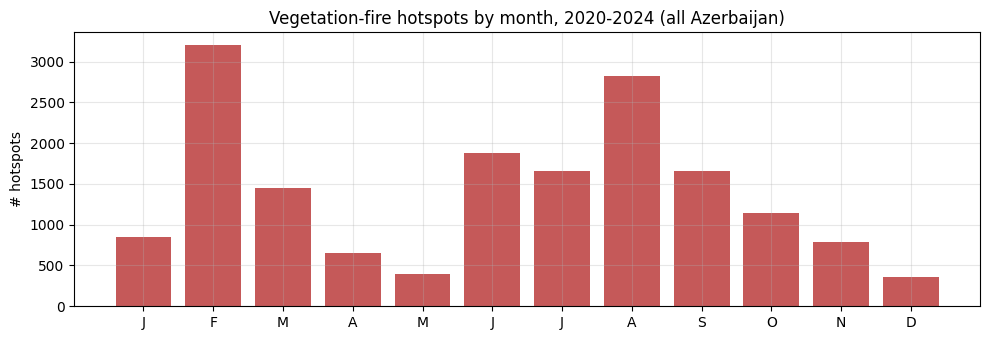

In [32]:
f = firms[(firms["type"]==0) & (firms["confidence"]!="l")]
monthly_counts = f["acq_date"].dt.month.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(monthly_counts.index, monthly_counts.values, alpha=0.75, color="firebrick")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_title("Vegetation-fire hotspots by month, 2020-2024 (all Azerbaijan)")
ax.set_ylabel("# hotspots"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The bimodal pattern — winter peak (January-February) and summer peak
(June-August) — is characteristic of human-caused agricultural burning plus
genuine summer wildfires. **Most Azerbaijan fires are human-set**, which is
why the `human_activity_score` feature matters.

## 3. Build the full feature matrix

In [33]:
feats = wf.build_wildfire_features()
print(f"Output shape: {feats.shape}")
print(f"Columns ({feats.shape[1]}):")
for c in feats.columns:
    print(f"  {c}")

20:18:19 | INFO    | src.wildfire.features | ========================================================================
20:18:19 | INFO    | src.wildfire.features | PHASE 4.1 - Wildfire feature engineering
20:18:19 | INFO    | src.wildfire.features | ========================================================================
20:18:19 | INFO    | src.wildfire.features | Cities in weather: ['Baku', 'Ganja', 'Guba', 'Lankaran', 'Zaqatala']
20:18:19 | INFO    | src.wildfire.features | FIRMS filtered: 16850 vegetation hotspots
20:18:19 | INFO    | src.wildfire.features | Fire-day rows (non-zero): 1315 across 5 cities
20:18:19 | INFO    | src.wildfire.features | Labeled rows: 9135 (fire-days: 1315, 14.40% positive)
20:18:19 | INFO    | src.wildfire.features | Added drought_index and dry_days_run
20:18:19 | INFO    | src.wildfire.features | Heatwave thresholds (p90): {'Baku': 32.25, 'Ganja': 32.7, 'Guba': 29.75, 'Lankaran': 30.25, 'Zaqatala': 29.57}
20:18:20 | INFO    | src.wildfire.features | Add

Output shape: (11500, 37)
Columns (37):
  City
  date
  temperature_2m_mean
  temperature_2m_min
  temperature_2m_max
  relative_humidity_2m_mean
  dew_point_2m_mean
  precipitation_sum
  rain_sum
  cloud_cover_mean
  vapour_pressure_deficit_mean
  wind_speed_10m_mean
  wind_speed_10m_max
  wind_gusts_10m_max
  wind_direction_10m
  soil_temperature_0_to_7cm_mean
  sunshine_duration_sum
  shortwave_radiation_mean
  fire_count
  fire_frp_total
  fire_frp_max
  fire_occurred
  dry_days_run
  drought_index
  hot_day
  heatwave_active
  dir_persistence
  wind_spread
  ndvi
  ndvi_anomaly
  human_access_road_meters
  pop_density
  human_activity_score
  lightning_thunder_hours
  month
  doy
  year


### 3a. Positive-class rate per city and per year

In [34]:
labelled = feats.dropna(subset=["fire_occurred"])

per_city = labelled.groupby("City")["fire_occurred"].agg(
    n_rows="count", fire_days="sum", positive_rate="mean"
).round(3)
print("Per city:")
print(per_city)

per_year = (
    labelled.assign(year=pd.to_datetime(labelled["date"]).dt.year)
    .groupby("year")["fire_occurred"]
    .agg(n_rows="count", fire_days="sum", positive_rate="mean")
    .round(3)
)
print("\nPer year:")
print(per_year)

Per city:
          n_rows  fire_days  positive_rate
City                                      
Baku        1827      492.0          0.269
Ganja       1827      296.0          0.162
Guba        1827      207.0          0.113
Lankaran    1827      165.0          0.090
Zaqatala    1827      155.0          0.085

Per year:
      n_rows  fire_days  positive_rate
year                                  
2020    1830      310.0          0.169
2021    1825      278.0          0.152
2022    1825      291.0          0.159
2023    1825      228.0          0.125
2024    1830      208.0          0.114


## 4. Visualise the derived features for one city-year

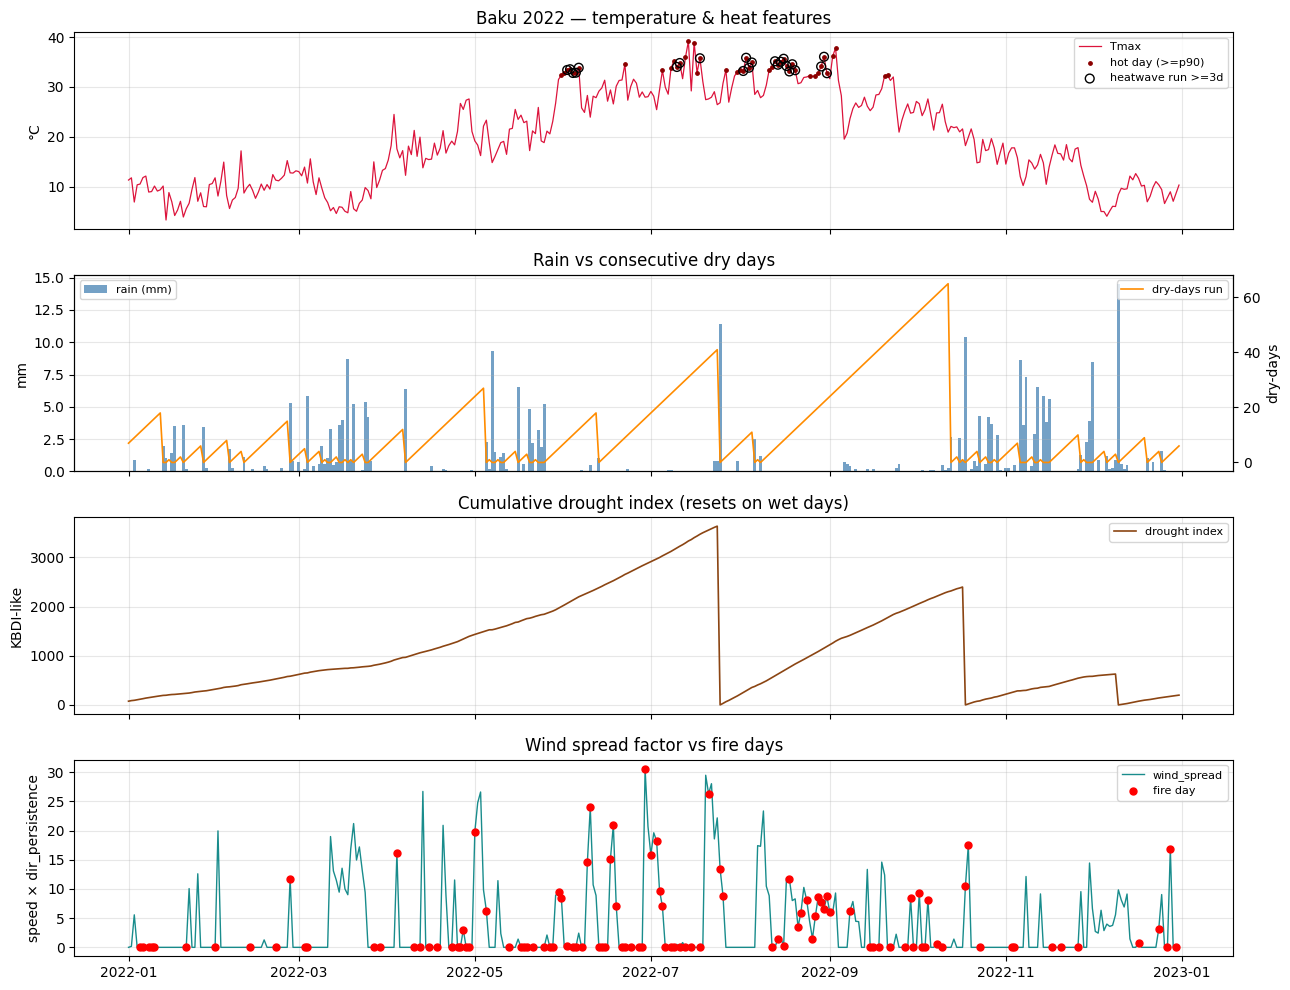

In [35]:
baku = feats[(feats["City"]=="Baku")
             & (feats["date"] >= "2022-01-01")
             & (feats["date"] <= "2022-12-31")].copy()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

ax = axes[0]
ax.plot(baku["date"], baku["temperature_2m_max"], lw=0.9, color="crimson", label="Tmax")
ax.scatter(baku.loc[baku["hot_day"]==1, "date"],
           baku.loc[baku["hot_day"]==1, "temperature_2m_max"],
           s=6, color="darkred", label="hot day (>=p90)", zorder=3)
ax.scatter(baku.loc[baku["heatwave_active"]==1, "date"],
           baku.loc[baku["heatwave_active"]==1, "temperature_2m_max"],
           s=40, facecolors="none", edgecolors="black", label="heatwave run >=3d", zorder=4)
ax.set_ylabel("°C"); ax.set_title("Baku 2022 — temperature & heat features")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(baku["date"], baku["rain_sum"], width=1.0, alpha=0.75, color="steelblue", label="rain (mm)")
ax2 = ax.twinx()
ax2.plot(baku["date"], baku["dry_days_run"], color="darkorange", lw=1.2, label="dry-days run")
ax.set_ylabel("mm"); ax2.set_ylabel("dry-days")
ax.set_title("Rain vs consecutive dry days")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(baku["date"], baku["drought_index"], color="saddlebrown", lw=1.2, label="drought index")
ax.set_ylabel("KBDI-like")
ax.set_title("Cumulative drought index (resets on wet days)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[3]
ax.plot(baku["date"], baku["wind_spread"], color="teal", lw=1, alpha=0.9, label="wind_spread")
ax.scatter(baku.loc[baku["fire_occurred"]==1, "date"],
           baku.loc[baku["fire_occurred"]==1, "wind_spread"],
           s=25, color="red", label="fire day", zorder=3)
ax.set_ylabel("speed × dir_persistence")
ax.set_title("Wind spread factor vs fire days")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Feature/target correlations

Pearson correlations with `fire_occurred` — a first sanity check that the
engineered features point the right way.

In [36]:
lbl = feats.dropna(subset=["fire_occurred"]).copy()
cols = ["temperature_2m_max", "rain_sum", "drought_index", "dry_days_run",
        "hot_day", "heatwave_active", "wind_spread", "ndvi_anomaly",
        "human_activity_score", "lightning_thunder_hours",
        "relative_humidity_2m_mean", "wind_speed_10m_max"]
rows = []
for c in cols:
    if c not in lbl.columns:
        continue
    r = lbl[c].corr(lbl["fire_occurred"])
    n = int(lbl[c].notna().sum())
    rows.append({"feature": c, "corr_with_fire": round(r, 3), "n": n})
pd.DataFrame(rows).sort_values("corr_with_fire", ascending=False, key=abs)

,feature,corr_with_fire,n
10,relative_humidity_2m_mean,-0.200,9135
0,temperature_2m_max,0.199,9135
8,human_activity_score,0.152,9135
11,wind_speed_10m_max,0.144,9135
2,drought_index,0.124,9135
4,hot_day,0.121,9135
3,dry_days_run,0.120,9135
1,rain_sum,-0.106,9135
5,heatwave_active,0.084,9135
6,wind_spread,0.070,9135


The pattern is physically sensible:
- Temperature and drought increase fire risk (positive correlation).
- Rain and humidity decrease it (negative).
- Lightning correlates *negatively* because Azerbaijan's winter agricultural
  burning dominates the fire count and happens when thunder-hours are minimal.
  This is an honest data observation, not a bug.

## 6. NDVI sanity check

NDVI is a 16-day composite from MODIS. We interpolate its DOY climatology to
a dense 366-day grid so every daily row has a defined `ndvi_anomaly`.

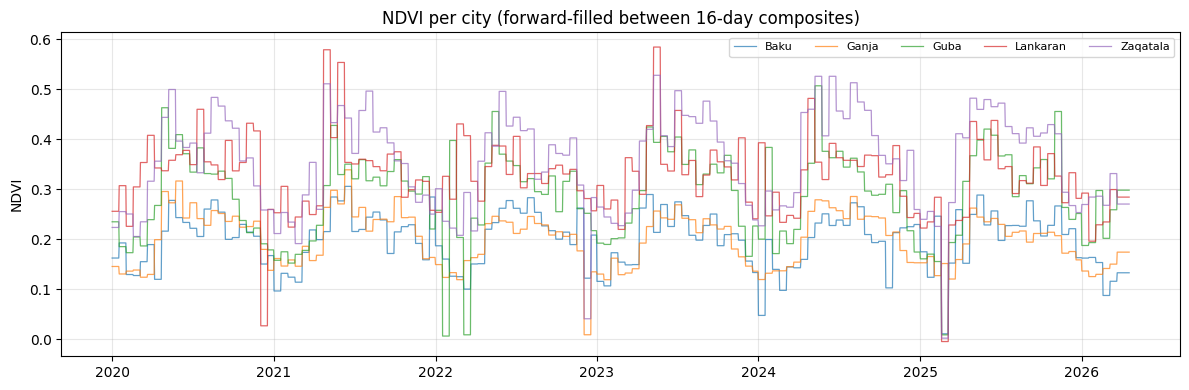

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))
for city, g in feats.groupby("City"):
    g_sorted = g.sort_values("date")
    ax.plot(g_sorted["date"], g_sorted["ndvi"], lw=0.9, alpha=0.7, label=city)
ax.set_title("NDVI per city (forward-filled between 16-day composites)")
ax.set_ylabel("NDVI"); ax.legend(fontsize=8, ncol=5); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Predictor inventory

In [40]:
predictors = wf.predictor_columns(feats)
print(f"Predictor count: {len(predictors)}")
categories = {
    "weather":   [c for c in predictors if any(k in c for k in
                  ["temperature_","humidity","dew_point","precipitation",
                   "rain","cloud","vapour","wind","soil","sunshine","radiation"])],
    "derived_fire": [c for c in predictors if c in
                    {"drought_index","dry_days_run","hot_day","heatwave_active",
                     "dir_persistence","wind_spread","ndvi","ndvi_anomaly"}],
    "human":    [c for c in predictors if c in
                {"human_access_road_meters","pop_density","human_activity_score",
                 "lightning_thunder_hours"}],
    "calendar": [c for c in predictors if c in {"month","doy","year"}],
}
cat_rows = [{"category": k, "n": len(v), "example_cols": ", ".join(v[:3])}
            for k, v in categories.items()]
pd.DataFrame(cat_rows)

Predictor count: 31


,category,n,example_cols
0,weather,17,"temperature_2m_mean, temperature_2m_min, tempe..."
1,derived_fire,8,"dry_days_run, drought_index, hot_day"
2,human,4,"human_access_road_meters, pop_density, human_a..."
3,calendar,3,"month, doy, year"


## 8. Persisted artefacts

In [39]:
out = PROCESSED_DIR / "wildfire_features.csv"
if out.exists():
    print(f"  {out.name:30s} {out.stat().st_size/1024/1024:6.2f} MB")
    print(f"  Rows: {len(pd.read_csv(out)):,}")

  wildfire_features.csv            3.91 MB
  Rows: 11,500


---
**Step 1 of Phase 4 ✅ complete.** Next: `08_wildfire_modeling.ipynb` — classification
and regression models for fire occurrence and count.